# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

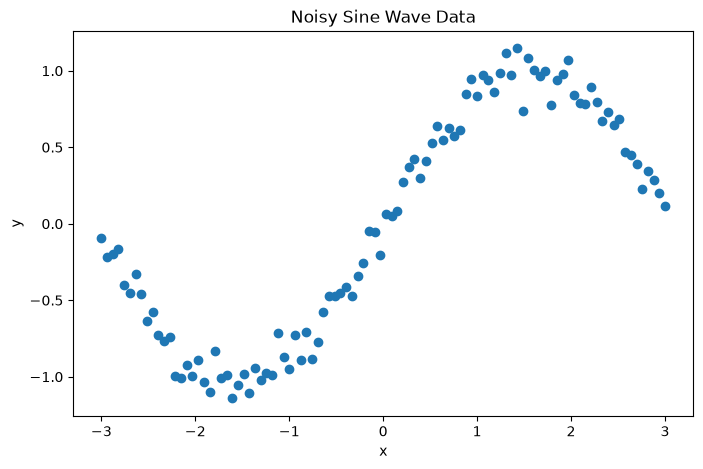

In [2]:
# Generate toy data

x = np.linspace(-3, 3, 100)

y = np.sin(x) + np.random.normal(
    0,
    0.1,
    100
)

plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.title("Noisy Sine Wave Data")
plt.xlabel("x")
plt.ylabel("y")

plt.show()


In [3]:


w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

print("w =", w)
print("b =", b)


w = -0.14153707420504144
b = -0.04206453227653591


In [4]:
lr = 0.05

losses = []

for step in range(200):

    y_hat = w * x + b

    loss = np.mean((y_hat - y) ** 2)

    dw = np.mean(2 * (y_hat - y) * x)

    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

    losses.append(loss)

print("Final loss:", loss)

Final loss: 0.1954517971396205


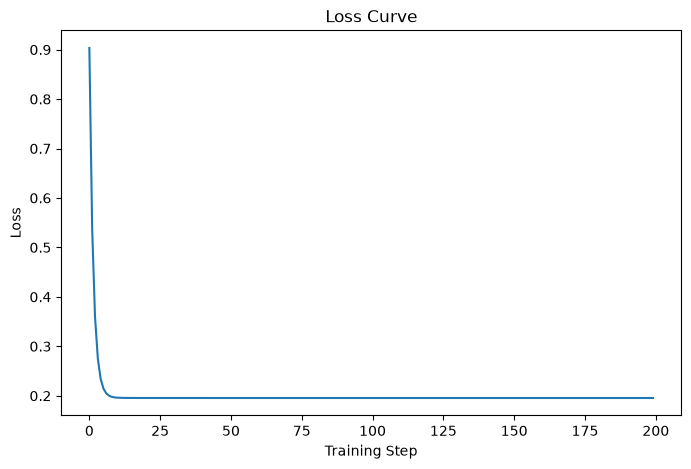

In [5]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.show()

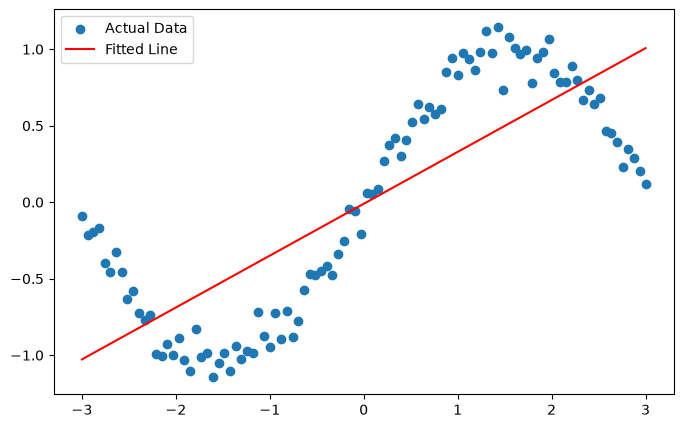

In [6]:
y_hat = w * x + b

plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Actual Data")

plt.plot(
    x,
    y_hat,
    color="red",
    label="Fitted Line"
)

plt.legend()

plt.show()

answer:

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

In [7]:
# Initialize parameters

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

# Reshape data
x_nn = x.reshape(-1, 1)
y_nn = y.reshape(-1, 1)

lr = 0.05

losses = []

# Training loop
for step in range(3000):

    # Forward pass
    z1 = x_nn @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_nn) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y_nn) / len(y_nn)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x_nn.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

print("Final Loss:", loss)

Final Loss: 0.014841292390220518


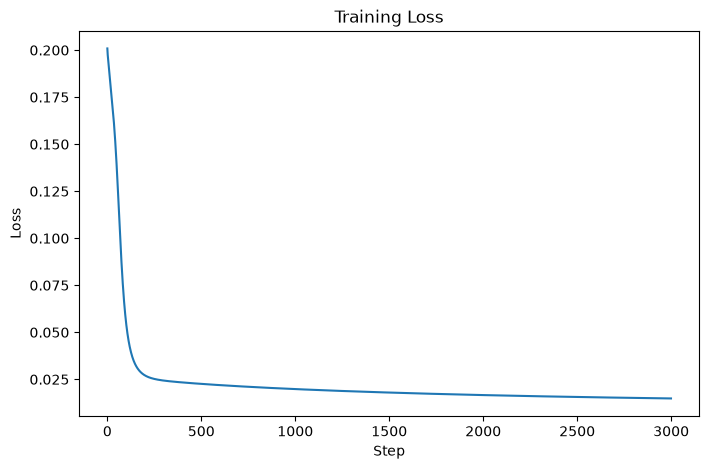

In [8]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")

plt.show()

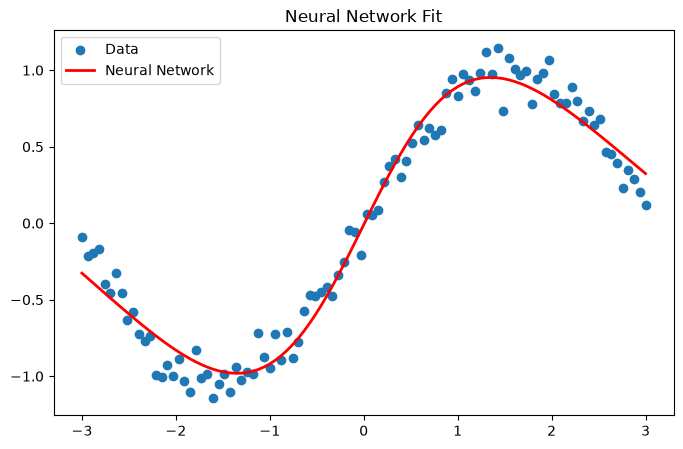

In [9]:
z1 = x_nn @ W1 + b1
h = np.tanh(z1)

y_pred = h @ W2 + b2

plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Data")

plt.plot(
    x,
    y_pred,
    color="red",
    linewidth=2,
    label="Neural Network"
)

plt.legend()
plt.title("Neural Network Fit")

plt.show()

In [10]:
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros((1, 8))

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros((1, 1))

losses_linear = []

for step in range(3000):

    z1 = x_nn @ W1_linear + b1_linear

    h = z1      # tanh removed

    y_hat = h @ W2_linear + b2_linear

    loss = np.mean((y_hat - y_nn) ** 2)

    d_yhat = 2 * (y_hat - y_nn) / len(y_nn)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    dz1 = dh

    dW1 = x_nn.T @ dz1
    db1 = dz1.sum(axis=0)

    W1_linear -= 0.05 * dW1
    b1_linear -= 0.05 * db1

    W2_linear -= 0.05 * dW2
    b2_linear -= 0.05 * db2

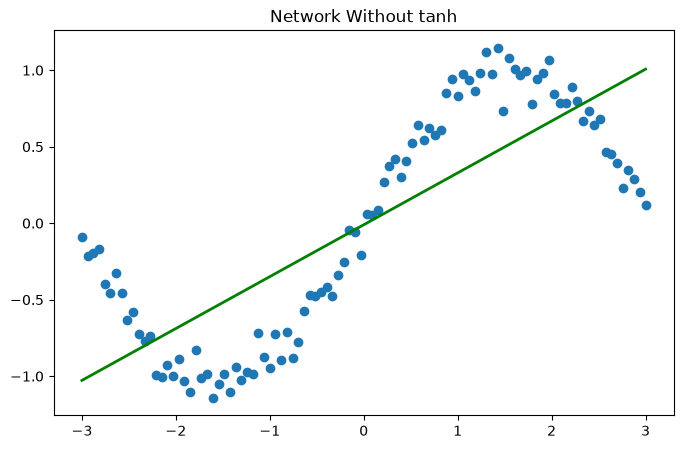

In [11]:
z1 = x_nn @ W1_linear + b1_linear
h = z1

y_pred_linear = h @ W2_linear + b2_linear

plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.plot(
    x,
    y_pred_linear,
    color="green",
    linewidth=2
)

plt.title("Network Without tanh")

plt.show()

answer-

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [Double-click to edit]

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.